In [ ]:
from pathlib import Path
import runpy

BOOTSTRAP_CANDIDATES = (
    "notebooks/_bootstrap.py",
    "abstractgraph/notebooks/_bootstrap.py",
    "abstractgraph-ml/notebooks/_bootstrap.py",
    "abstractgraph-generative/notebooks/_bootstrap.py",
    "abstractgraph-graphicalizer/notebooks/_bootstrap.py",
)

_bootstrap_path = next(
    (
        candidate / relative
        for candidate in (Path.cwd(), *Path.cwd().parents)
        for relative in BOOTSTRAP_CANDIDATES
        if (candidate / relative).exists()
    ),
    None,
)
if _bootstrap_path is None:
    raise FileNotFoundError("Could not locate ecosystem notebooks/_bootstrap.py")

_bootstrap = runpy.run_path(str(_bootstrap_path))
repo_root = _bootstrap["repo_root"]
workspace_root = _bootstrap["workspace_root"]


# Image-Conditioned Autoregressive Molecule Generation
Build base graphs under a fixed, immutable interpretation graph context.

## Rewiring Sequence
1. Choose a conditioned interpretation graph and keep it fixed for the whole sample.
2. Build a BFS order over interpretation nodes (rooted at a high-degree node).
3. At each interpretation node, retrieve candidate donor mapped subgraphs from the cut index by role hash.
4. Filter candidates by anchor compatibility and required neighbor-overlap signature.
5. Sample anchor mappings from current base nodes and merge the donor mapped subgraph into the current graph.
6. Enforce image-edge constraints (including exact `shared_preimage_nodes` equality when present).
7. Apply feasibility checks, then score/rank surviving candidates (context + usage + failure-aware penalties).
8. Recurse to the next interpretation node; on failure, backtrack and avoid retrying the same mapped subgraph in the same local state.
9. Stop when all interpretation nodes are materialized (success) or DFS/time budgets are exhausted (failure).


In [1]:
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2


In [2]:
from abstractgraph_graphicalizer.chem import draw_molecules as display_graphs
import time
import random
import multiprocessing as mp
import networkx as nx
from abstractgraph.hashing import hash_graph, GraphHashDeduper
from abstractgraph_generative.conditional import (
    display_conditioned_graphs,
    build_image_conditioned_cut_index_from_pruning,
)

def _fmt_elapsed(seconds):
    """Format elapsed seconds as s, m, or h with two decimals.

    Args:
        seconds: Elapsed time in seconds.

    Returns:
        Human-readable duration string.
    """
    seconds = float(seconds)
    if seconds < 60:
        return f"{seconds:.2f}s"
    if seconds < 3600:
        return f"{seconds/60:.2f}m"
    return f"{seconds/3600:.2f}h"

def group_graphs_by_interpretation_hash(graphs, decomposition_function, nbits, label_mode="graph_hash"):
    """Group graphs by the hash of their interpretation graph."""
    buckets = {}
    for g in graphs:
        ag = graph_to_abstract_graph(
            g,
            decomposition_function=decomposition_function,
            nbits=nbits,
            label_mode=label_mode,
        )
        img_hash = hash_graph(ag.interpretation_graph)
        buckets.setdefault(img_hash, []).append(g)
    return buckets


def select_interpretation_group(buckets, min_group_size):
    """Pick a group of graphs sharing the same image hash.

    Prefers a random group with size >= min_group_size; otherwise uses the largest group.
    Returns (selected_group, used_fallback).
    """
    if not buckets:
        return [], True
    eligible = [g for g in buckets.values() if len(g) >= min_group_size]
    if eligible:
        return random.choice(eligible), False
    return max(buckets.values(), key=len), True


def build_cut_index_from_pruning(
    generator_graphs,
    decomposition_function,
    nbits,
    n_pruning_iterations,
    base_cut_radius,
    interpretation_cut_radius,
    label_mode="graph_hash",
    preimage_context_radius=None,
    image_context_radius=None,
    context_vectorizer=None,
    use_context_embedding=False,
    max_num_anchors=None,
    max_num_anchor_sets_retry=None,
    seed=None,
):
    """Build a cut index by pruning a list of generator graphs.

    This keeps the interpretation graph fixed and consistent with each source graph
    by using mapped-subgraph-aware pruning.
    """
    return build_image_conditioned_cut_index_from_pruning(
        generator_graphs,
        decomposition_function,
        nbits,
        n_pruning_iterations=n_pruning_iterations,
        base_cut_radius=base_cut_radius,
        interpretation_cut_radius=interpretation_cut_radius,
        preimage_context_radius=preimage_context_radius,
        image_context_radius=image_context_radius,
        context_vectorizer=context_vectorizer,
        use_context_embedding=use_context_embedding,
        max_num_anchors=max_num_anchors,
        max_num_anchor_sets_retry=max_num_anchor_sets_retry,
        seed=seed,
        label_mode=label_mode,
    )


def generate_graphs(
    graphs,
    generator,
    generator_size=1,
    n_samples=1,
    n_pruning_iterations=50,
    constraint_level=None,
    use_context_embedding=None,
    use_transition_primary=None,
    mode='same_image',
    label_mode=None,
    display_n_graphs_per_line=3,
    verbose=True,
    return_history=False,
    max_attempts_multiplier=8,
    random_seed=None,
    generator_selection_seed=None,
    generation_seed=None,
    render_outputs=False,
    n_jobs_override=1,
):

    if label_mode is None:
        label_mode = getattr(generator, "label_mode", "graph_hash")

    if getattr(generator, 'decomposition_function', None) is None:
        raise ValueError('generator.decomposition_function must be initialized.')
    if getattr(generator, 'nbits', None) is None:
        raise ValueError('generator.nbits must be initialized.')

    if use_transition_primary is not None:
        generator.use_transition_primary = bool(use_transition_primary)

    # Backward compatibility: random_seed fixes both selection and generation.
    if random_seed is not None:
        random_seed = int(random_seed)
    if generator_selection_seed is None:
        generator_selection_seed = random_seed
    if generation_seed is None and random_seed is not None:
        generation_seed = random_seed

    if mode == 'nn':
        vec = generator.context_vectorizer
        # Force parallel vectorizer for NN selection.
        try:
            vec.n_jobs = min(12, mp.cpu_count())
        except Exception:
            pass
        try:
            vec.backend = "loky"
        except Exception:
            pass
        if verbose:
            try:
                print(f"vectorizer n_jobs={getattr(vec, 'n_jobs', None)} backend={getattr(vec, 'backend', None)}")
            except Exception:
                pass

    t0 = time.perf_counter()

    generator_graphs, interpretation_graph = generator.prepare_from_graphs(
        graphs,
        generator_size=generator_size,
        n_pruning_iterations=n_pruning_iterations,
        constraint_level=constraint_level,
        use_context_embedding=use_context_embedding,
        mode=mode,
        label_mode=label_mode,
        seed=generator_selection_seed,
        verbose=verbose,
    )
    if not generator_graphs:
        if verbose:
            print('No graphs available; aborting.')
        return ([], []) if return_history else []

    max_attempts = max(1, int(n_samples) * max(1, int(max_attempts_multiplier)))
    interpretation_graph_for_generation = interpretation_graph if mode == 'same_image' else None
    if generation_seed is None:
        rng_for_generation = random.Random()
    else:
        rng_for_generation = random.Random(int(generation_seed))

    prev_n_jobs = getattr(generator, 'n_jobs', None)
    if n_jobs_override is not None:
        generator.n_jobs = int(n_jobs_override)
    try:
        result = generator.generate(
            n_samples=max(0, int(n_samples)),
            interpretation_graph=interpretation_graph_for_generation,
            rng=rng_for_generation,
            return_history=bool(return_history),
            max_attempts=max_attempts,
            verbose=verbose,
        )
    finally:
        if n_jobs_override is not None:
            generator.n_jobs = prev_n_jobs
    if return_history:
        samples, histories = result
    else:
        samples = result
        histories = []

    if verbose:
        print(f'generation returned: {len(samples)} samples (n_jobs_override={n_jobs_override})')

    if mode == 'same_image':
        interpretation_graph = getattr(generator, 'last_prepared_interpretation_graph', None)
    else:
        interpretation_graphs = list(getattr(generator, 'interpretation_graphs', []))
        interpretation_graph = interpretation_graphs[0] if interpretation_graphs else None

    if verbose:
        if interpretation_graph is not None:
            display_conditioned_graphs(
                generator_graphs,
                interpretation_graph,
                decomposition_function=getattr(generator, 'decomposition_function', None),
                nbits=getattr(generator, 'nbits', None),
                label_mode=label_mode,
                per_graph_interpretation_graphs=True,
                n_graphs_per_line=display_n_graphs_per_line,
                show=True,
            )
    t1 = time.perf_counter()
    if verbose:
        print(f'Cut index build time: {_fmt_elapsed(t1 - t0)}')
    target = max(0, int(n_samples))
    if len(samples) < target and verbose:
        print(f'Warning: only {len(samples)}/{target} samples after feasibility filtering.')
    if verbose:
        print('Generated graphs:')
        display_graphs(samples)
        for idx, hist in enumerate(histories):
            build_up = list(hist)
            titles = [f"inst {idx} | step {i}" for i in range(len(build_up))]
            if mode == 'same_image':
                display_conditioned_graphs(
                    build_up,
                    interpretation_graph,
                    n_graphs_per_line=display_n_graphs_per_line,
                    titles=titles,
                    show=True,
                )
            else:
                display_conditioned_graphs(
                    build_up,
                    interpretation_graph,
                    n_graphs_per_line=display_n_graphs_per_line,
                    titles=titles,
                    show=True,
                )


    print(f'generator_graphs: {len(generator_graphs)}')
    display_graphs(generator_graphs)

    print(f'samples: {len(samples)}')

    novel_samples = GraphHashDeduper().fit(generator_graphs).filter(samples)
    print(f'novel samples: {len(novel_samples)}')
    display_graphs(novel_samples)
    print('All generated samples:')
    display_graphs(samples)
    return (samples, histories) if return_history else samples


def generate_dataset(
    graphs,
    targets_or_generator,
    generator=None,
    graph_estimator=None,
    constraint_level=1,
    use_context_embedding=False,
    cluster_size=10,
    size_factor=1,
    verbose=True,
    max_attempts_multiplier=8,
):
    import math
    import numpy as _np
    try:
        from scipy.cluster.hierarchy import linkage, fcluster
    except Exception as exc:
        raise ImportError('scipy is required for Ward hierarchical clustering') from exc

    graphs = list(graphs or [])
    if generator is None:
        generator = targets_or_generator
        targets = None
    else:
        targets = list([] if targets_or_generator is None else targets_or_generator)
    if not graphs:
        return ([], []) if targets is not None else []
    if targets is not None and len(targets) != len(graphs):
        raise ValueError('targets must have the same length as graphs')
    if getattr(generator, 'context_vectorizer', None) is None:
        raise ValueError('generator.context_vectorizer is required.')
    if int(cluster_size) <= 0:
        raise ValueError('cluster_size must be > 0')
    if getattr(generator, 'decomposition_function', None) is None:
        raise ValueError('generator.decomposition_function must be initialized.')
    if getattr(generator, 'nbits', None) is None:
        raise ValueError('generator.nbits must be initialized.')

    if use_transition_primary is not None:
        generator.use_transition_primary = bool(use_transition_primary)

    if random_seed is not None:
        random_seed = int(random_seed)
        random.seed(random_seed)
        try:
            import numpy as _np
            _np.random.seed(random_seed)
        except Exception:
            pass

    vec = generator.context_vectorizer
    feats = _np.asarray(vec.fit_transform(graphs), dtype=float)
    if feats.ndim != 2 or feats.shape[0] != len(graphs):
        raise ValueError('context_vectorizer returned invalid feature shape')

    n = len(graphs)
    n_clusters = max(1, int(math.ceil(float(n) / float(cluster_size))))
    if n == 1:
        labels = _np.asarray([1], dtype=int)
    else:
        z = linkage(feats, method='ward')
        labels = _np.asarray(fcluster(z, t=n_clusters, criterion='maxclust'), dtype=int)

    clustered = {}
    for idx, lbl in enumerate(labels.tolist()):
        clustered.setdefault(int(lbl), []).append(idx)

    # Ensure each processed group has at most cluster_size elements.
    groups = []
    csize = int(cluster_size)
    for lbl in sorted(clustered.keys()):
        idxs = clustered[lbl]
        for start in range(0, len(idxs), csize):
            groups.append(idxs[start:start + csize])

    # Merge undersized groups into nearest groups (by embedding centroid).
    # This may produce groups larger than cluster_size, which is acceptable.
    if len(groups) > 1 and n >= csize:
        while True:
            small = [gi for gi, g in enumerate(groups) if len(g) < csize]
            if not small:
                break
            gi = small[0]
            if len(groups) <= 1:
                break
            ci = feats[_np.asarray(groups[gi], dtype=int)].mean(axis=0)
            best_j = None
            best_d = None
            for gj, g in enumerate(groups):
                if gj == gi:
                    continue
                cj = feats[_np.asarray(g, dtype=int)].mean(axis=0)
                d = float(_np.linalg.norm(ci - cj))
                if best_d is None or d < best_d:
                    best_d = d
                    best_j = gj
            if best_j is None:
                break
            groups[best_j] = groups[best_j] + groups[gi]
            del groups[gi]

    requested_per_group = [
        int(round(float(len(idxs)) * float(size_factor))) for idxs in groups
    ]
    if any(req <= 0 for req in requested_per_group):
        if verbose:
            print('requested samples for at least one cluster is <= 0; returning empty dataset')
        return ([], []) if targets is not None else []

    out = []
    out_targets = [] if targets is not None else None
    n_groups = len(groups)
    total_requested = sum(requested_per_group)
    recent_elapsed = []
    if verbose:
        print(f"{'cluster':>9} | {'size':>4} | {'generated':>11} | {'cumulative':>20} | {'elapsed':>10} | {'eta':>10}")
    for i, idxs in enumerate(groups, start=1):
        requested = requested_per_group[i - 1]
        cluster_graphs = [graphs[j] for j in idxs]
        t0 = time.perf_counter()
        samples = generator.generate_from_graphs(
            cluster_graphs,
            n_samples=requested,
            generator_size=len(cluster_graphs),
            constraint_level=constraint_level,
            use_context_embedding=use_context_embedding,
            mode='nn',
            label_mode=getattr(generator, 'label_mode', None),
            max_attempts_multiplier=max(1, int(max_attempts_multiplier)),
            return_history=False,
            verbose=False,
        )
        elapsed = time.perf_counter() - t0
        out.extend(samples)
        if out_targets is not None:
            cluster_targets = [targets[j] for j in idxs]
            if cluster_targets:
                out_targets.extend(
                    cluster_targets[k % len(cluster_targets)] for k in range(len(samples))
                )
        recent_elapsed.append(float(elapsed))
        if len(recent_elapsed) > 2:
            recent_elapsed = recent_elapsed[-2:]
        if verbose:
            cum = len(out)
            frac_pct = (100.0 * float(cum) / float(total_requested)) if total_requested > 0 else 0.0
            remaining = max(0, n_groups - i)
            avg_recent = (sum(recent_elapsed) / float(len(recent_elapsed))) if recent_elapsed else 0.0
            eta_seconds = avg_recent * float(remaining)
            cluster_str = f"{i:>2}/{n_groups:<2}"
            generated_str = f"{len(samples):>3}/{requested:<3}"
            cumulative_str = f"{cum:>4}/{total_requested:<4} ({frac_pct:5.1f}%)"
            elapsed_str = _fmt_elapsed(elapsed)
            eta_str = _fmt_elapsed(eta_seconds)
            print(
                f"{cluster_str:>9} | {len(cluster_graphs):>4} | {generated_str:>11} | "
                f"{cumulative_str:>20} | {elapsed_str:>10} | {eta_str:>10}"
            )

    if verbose:
        print(f'total generated={len(out)} across {n_groups} clusters')
    if out_targets is not None and graph_estimator is not None:
        graph_estimator.fit(graphs, targets)
        out_targets = graph_estimator.predict(out)
    return (out, out_targets) if out_targets is not None else out


In [3]:
import warnings
import matplotlib.pyplot as plt
from abstractgraph.utils import plot_embedding_2d
def _compute_embeddings(graph_estimator, graphs):
    try:
        import umap.umap_ as umap

        embs = graph_estimator.transform(graphs)
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message=r".*n_jobs value .* overridden .* by setting random_state.*",
                category=UserWarning,
                module="umap.umap_",
            )
            Z = umap.UMAP(n_components=2, random_state=42, init="random").fit_transform(embs)
        return Z
    except Exception:
        return None
    

def plot(graph_estimator, graphs, targets, quantile=.9):
    alpha=.65
    size = 6
    embeddings = _compute_embeddings(graph_estimator, graphs)
    fig, axes = plt.subplots(1, 3, figsize=(3.1*size, size), constrained_layout=True)
    _ = plot_embedding_2d(graph_estimator, graphs, targets, title_prefix="Train embeddings", mode="scatter", alpha=alpha, ax=axes[0], show=False, Z=embeddings, quantile=quantile)
    _ = plot_embedding_2d(graph_estimator, graphs, targets, title_prefix="Train embeddings", mode="class_union", k=5, alpha=alpha, z=1, ax=axes[1], show=False, show_instances=False, Z=embeddings, quantile=quantile)
    _ = plot_embedding_2d(graph_estimator, graphs, targets, title_prefix="Train embeddings", mode="class_union", k=11, alpha=alpha, z=1, ax=axes[2], show=False, show_instances=False, Z=embeddings, quantile=quantile)
    plt.show()

In [4]:
import time
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split

def perf(graph_estimator, graphs, targets):    
    # Train metrics
    t_pred0 = time.perf_counter()
    pred = graph_estimator.predict(graphs)
    try:
        proba = graph_estimator.predict_proba(graphs)
    except Exception:
        proba = None
    t_pred1 = time.perf_counter()
    pred_time = t_pred1 - t_pred0
    acc = accuracy_score(targets, pred)
    errors = int((pred != targets).sum())
    if proba is not None and proba.ndim == 2 and proba.shape[1] > 1:
        if proba.shape[1] == 2:
            auc = roc_auc_score(targets, proba[:, 1])
            ap = average_precision_score(targets, proba[:, 1])
        else:
            auc = roc_auc_score(targets, proba, average='macro', multi_class='ovr')
            ap = average_precision_score(targets, proba, average='macro')
    else:
        auc, ap = None, None
    return acc, auc, ap, errors, pred_time



In [5]:
def estimated_predictive_performance(train_graphs, train_targets, test_graphs, test_targets):
    from nsppk import NSPPK
    vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True)
    train_X = vectorizer.transform(train_graphs)
    test_X = vectorizer.transform(test_graphs)
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)
    clf.fit(train_X, train_targets)
    from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
    y_prob = clf.predict_proba(test_X)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    acc = accuracy_score(test_targets, y_pred)
    print(f'Test accuracy: {acc:.3f} | ROC-AUC: {roc_auc_score(test_targets, y_prob):.3f} | AvgPrec: {average_precision_score(test_targets, y_prob):.3f}')

In [6]:
def estimated_generative_quality(generated_graphs, generated_targets, train_graphs, train_targets, reference_graphs, reference_targets, test_graphs, test_targets):
    from nsppk import NSPPK
    vectorizer = NSPPK(radius=1, distance=4, connector=1, nbits=14, parallel=True)

    from sklearn.ensemble import ExtraTreesClassifier
    classifier = ExtraTreesClassifier(n_estimators=300, n_jobs=-1, random_state=42)

    from abstractgraph_generative.generative_performance import compute_expected_gain_weighted_equivalent_data_size
    results = compute_expected_gain_weighted_equivalent_data_size(
        generated_graphs, generated_targets, train_graphs, train_targets, reference_graphs, reference_targets, test_graphs, test_targets,
        vectorizer=vectorizer, classifier=classifier,
        fracional_size=(1,2,3,4,5,7,10,15),
        n_repeats=30,
    )
    print(f'Expected gain weighted equivalent data size:{results["expected_gain_weighted_equivalent_data_size"]:.3f}')

    from abstractgraph_generative.generative_performance import plot_expected_gain_weighted_equivalent_data_size
    _ = plot_expected_gain_weighted_equivalent_data_size(results)

---

size: 303


[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 59 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 75 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 65 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 58 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 68 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 55 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 59 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 68 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 59 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 58 ignored
[17:57:54] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom

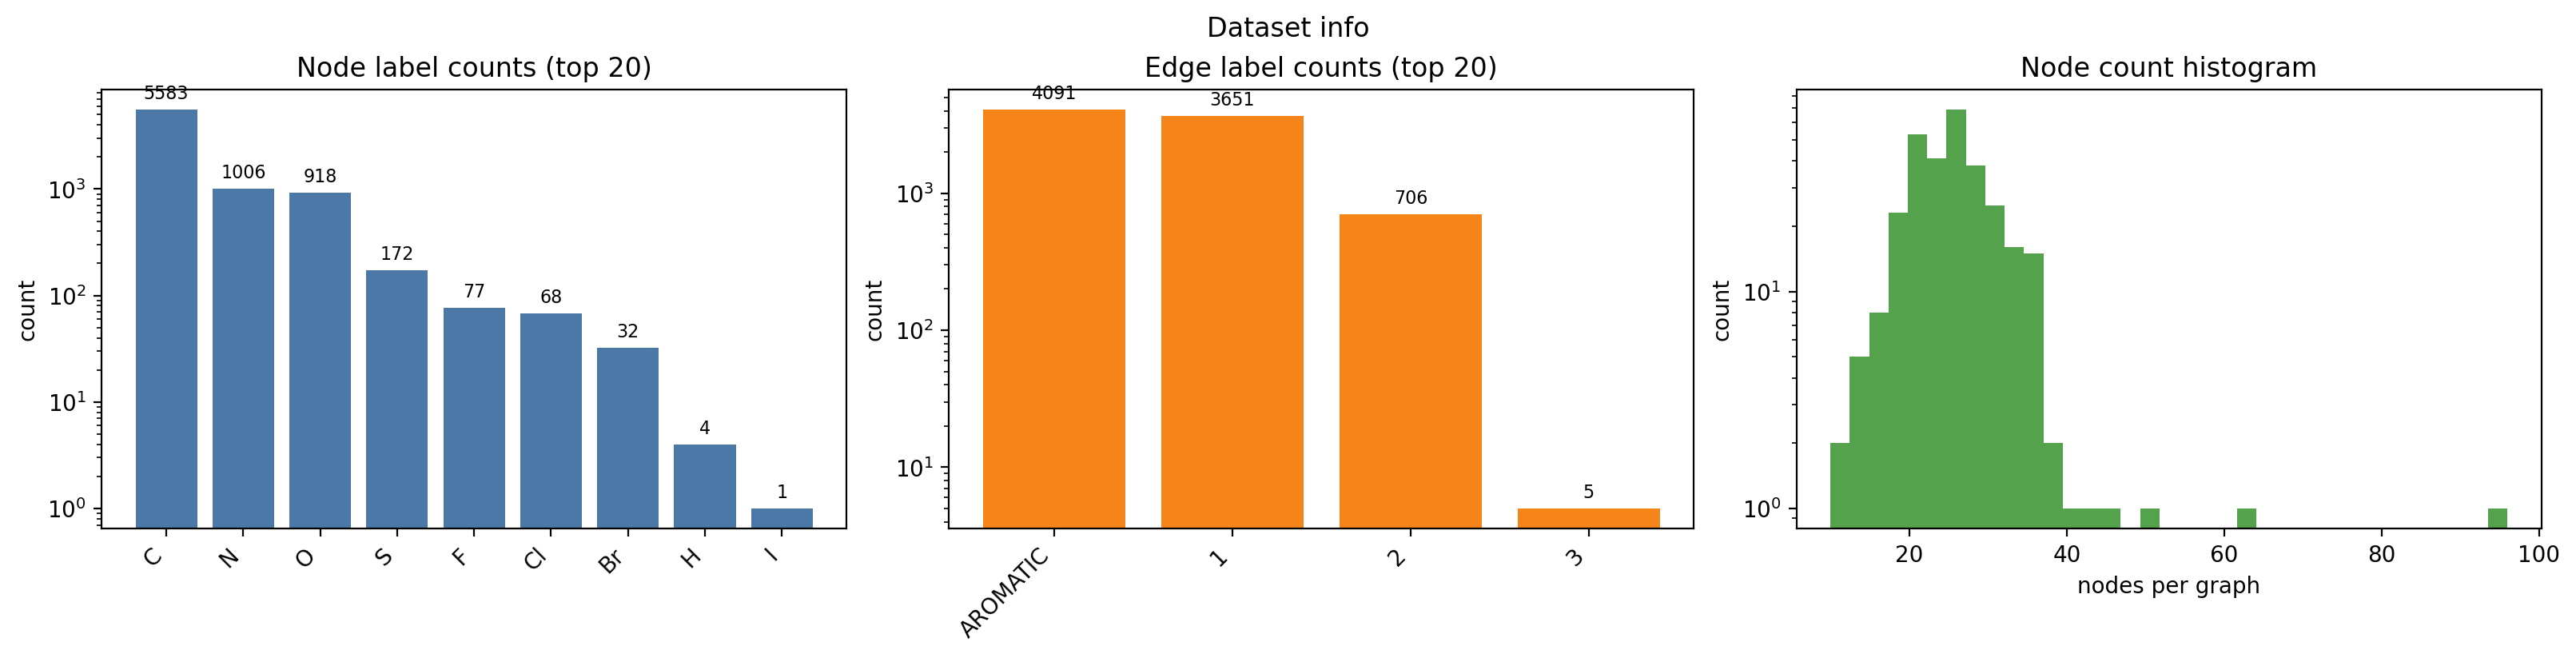

In [7]:
from abstractgraph_graphicalizer.chem import PubChemLoader

loader = PubChemLoader(on_error="skip")

assay_ids = ['2631','624249','651741','588350','463230','492952','743219','492992','463213']
assay_id = assay_ids[1]
assay_id = '624249' #bundled-safe assay example
size = int(100/.33) #to account for 0.33 for test and 0.5 for reference
print(f"size: {size}")
use_equalized = True


limit_active = int(size // 2) if use_equalized else int(size)
limit_inactive = int(size // 2) if use_equalized else int(size)
graphs, targets = loader.load(
    assay_id,
    limit_active=limit_active,
    limit_inactive=limit_inactive,
)
targets = np.array(targets)

from abstractgraph.utils import plot_graph_label_counts
_ = plot_graph_label_counts(graphs, top=20, title='Dataset info', log_scale=True)


In [ ]:
from sklearn.model_selection import train_test_split
test_size = 0.33
all_train_graphs, test_graphs, all_train_targets, test_targets = train_test_split(
    graphs,
    targets,
    test_size=test_size,
    stratify=targets if len(np.unique(targets)) > 1 else None,
    random_state=0,
)
reference_split_size = 0.5
train_graphs, reference_graphs, train_targets, reference_targets = train_test_split(
    all_train_graphs,
    all_train_targets,
    test_size=reference_split_size,
    stratify=all_train_targets if len(np.unique(all_train_targets)) > 1 else None,
    random_state=0,
)
print(f"AID {assay_id} graphs: {len(graphs)} (train={len(train_graphs)}, reference={len(reference_graphs)}, test={len(test_graphs)})")
#estimated_predictive_performance(train_graphs, train_targets, test_graphs, test_targets)

---

In [9]:
from abstractgraph.vectorize import AbstractGraphTransformer
from abstractgraph.operators import *
from abstractgraph_ml.feasibility import FeasibilityEstimatorFeatureCannotExist, FeasibilityEstimator
from abstractgraph.graphs import graph_to_abstract_graph
from abstractgraph_generative.conditional import (
    ConditionalAutoregressiveGenerator,
    display_conditioned_graphs,
)

df = compose(neighborhood(radius=2), unlabel())
fe1 = FeasibilityEstimatorFeatureCannotExist(decomposition_function=df, nbits=19, parallel=True, backend="dill")
df = add(neighborhood(radius=1), cycle())
fe2 = FeasibilityEstimatorFeatureCannotExist(decomposition_function=df, nbits=19, parallel=True, backend="dill")
feasibility_estimators = [fe1, fe2]
feasibility_estimator = FeasibilityEstimator(feasibility_estimators)

#------------------------------------------------------------------------------------------------------------------
nbits=14
label_mode="operator_hash"

df2 = compose(name('2'), filter_by_number_of_nodes(number_of_nodes=2), tree())
df3 = compose(name('3'), filter_by_number_of_nodes(number_of_nodes=3), tree())
df4 = compose(name('4+'), filter_by_number_of_nodes(number_of_nodes=(4,100)), tree())
df5 = compose(name('cycle<5'), filter_by_number_of_nodes(number_of_nodes=(3,4)), cycle())
df6 = compose(name('cycle-5-6'), filter_by_number_of_nodes(number_of_nodes=(5,6)), cycle())
df7 = compose(name('cycle>6'), filter_by_number_of_nodes(number_of_nodes=(7,100)), cycle())
df = add(df5, df2, df3, df4, df6, df7)
decomposition_function = compose(intersection_edges(), restore_label(), df, unlabel())

df1 = compose(name('2'), filter_by_number_of_nodes(number_of_nodes=(1,2)), neighborhood(radius=1))
df2 = compose(name('3'), filter_by_number_of_nodes(number_of_nodes=3), neighborhood(radius=1))
df3 = compose(name('4'), filter_by_number_of_nodes(number_of_nodes=4), neighborhood(radius=1))
df4 = compose(name('5+'), filter_by_number_of_nodes(number_of_nodes=(5,100)), neighborhood(radius=1))
df = add(df1, df2, df3, df4)
decomposition_function = compose(intersection_edges(), remove_redundant_associations(), df)



df1 = compose(name('p'), split(n_parts=2), filter_by_number_of_nodes(number_of_nodes=(1,15)), identity())
df2 = compose(name('p'), split(n_parts=4), filter_by_number_of_nodes(number_of_nodes=(16,25)), identity())
df3 = compose(name('p'), split(n_parts=6), filter_by_number_of_nodes(number_of_nodes=(26,35)), identity())
core_df = add(df1, df2, df3)
connector_df = compose(name('connect'), connected_component(), edge_complement(), merge(use_edges=True), core_df)
decomposition_function = compose(intersection_edges(), remove_redundant_associations(), add(core_df, connector_df))

df1 = compose(name('t'), filter_by_number_of_nodes(number_of_nodes=(1,3)), tree())
df2 = compose(name('t'), split(n_parts=2), filter_by_number_of_nodes(number_of_nodes=(4,100)), tree())
df3 = compose(name('c'),cycle())
core_df = add(df1, df2, df3)
connector_df = compose(name('connect'), connected_component(), edge_complement(), merge(use_edges=True), core_df)
decomposition_function = compose(intersection_edges(), remove_redundant_associations(), add(core_df, connector_df))


core_df = compose(name('cor'), connected_component(), betweenness_centrality_split(number_of_nodes=3))
connector_df = compose(name('con'), connected_component(), edge_complement(), merge(use_edges=True), core_df)
decomposition_function = compose(intersection_edges(), remove_redundant_associations(), add(connector_df, core_df))


df1 = compose(name('s'), filter_by_number_of_nodes(number_of_nodes=(1,3)), betweenness_centrality_hop_split(n_hops=1))
df2 = compose(name('l'), filter_by_number_of_nodes(number_of_nodes=(4,100)), betweenness_centrality_hop_split(n_hops=1))
decomposition_function = compose(intersection_edges(),remove_redundant_associations(), add(df1, df2)) 


df = add(compose(name('cyc'), cycle()), compose(name('tree'), tree()))
decomposition_function = compose(intersection_edges(), df)

core_df = compose(name('cor'),betweenness_centrality_hop_split(n_hops=1))
decomposition_function = compose(intersection_edges(),remove_redundant_associations(), core_df) 

core_df = compose(
    name('cor'),
    low_cut_partition(
        target_max_boundary_nodes=2,
        target_max_cut_edges=2,
        max_part_size=10,
        min_part_size=2,
        max_split_trials=12,
        balance_tolerance=0.25,
        max_depth=6,
        force_split_oversized=True,
        allow_small_parts=False,
        min_overlap_nodes=1,
        strict_max_boundary=True,
        prefer_low_attachment_split=True,
        low_attachment_max_edges=2,
        low_attachment_min_component_size=8,
        low_attachment_max_pair_trials=5000,
        seed=1,
    ),
)
connector_df = compose(name('connect'), connected_component(), edge_complement(), merge(use_edges=True), core_df)
decomposition_function = compose(intersection_edges(), remove_redundant_associations(), add(core_df, connector_df))

#------------------------------------------------------------------------------------------------------------------
graph_transformer = AbstractGraphTransformer(
    nbits=12,
    decomposition_function=add(edge(), cycle(), neighborhood(radius=(0,2))),
    return_dense=True,
)
# Use threads to avoid pickling issues with composed operators.
import multiprocessing as mp
graph_transformer.n_jobs = -1
graph_transformer.backend = "loky"

context_vectorizer= AbstractGraphTransformer(
    nbits=12,
    decomposition_function=edge(),
    return_dense=True,
    n_jobs=-1,
)

# Generation runtime profile
DEBUG_RESPONSIVE_PROFILE = True
if DEBUG_RESPONSIVE_PROFILE:
    n_jobs_cfg = 6
    min_attempts_per_job_cfg = 1
    max_dfs_seconds_cfg = 0.75
    max_candidates_per_bfs_node_cfg = 16
    max_anchor_matches_cfg = 1000
    transition_fallback_entry_budget_cfg = 96
else:
    n_jobs_cfg = 12
    min_attempts_per_job_cfg = 12
    max_dfs_seconds_cfg = 3.5
    max_candidates_per_bfs_node_cfg = 64
    max_anchor_matches_cfg = 5000
    transition_fallback_entry_budget_cfg = 256

generator = ConditionalAutoregressiveGenerator(
    decomposition_function=decomposition_function,
    nbits=nbits,
    feasibility_estimator=feasibility_estimator,
    apply_feasibility_during_construction = False,
    label_mode=label_mode,
    base_cut_radius=0,
    interpretation_cut_radius=0,
    preimage_context_radius=1,
    image_context_radius=1,
    max_num_anchors=4,
    max_num_anchor_sets_retry=5000,
    context_vectorizer=context_vectorizer,
    use_context_embedding=False,
    parallel_backend="loky",
    min_attempts_per_job=min_attempts_per_job_cfg,
    verbose_parallel_stats=True,
    n_jobs=n_jobs_cfg,
    max_dfs_seconds=max_dfs_seconds_cfg,
    max_candidates_per_bfs_node=max_candidates_per_bfs_node_cfg,
    max_anchor_matches=max_anchor_matches_cfg,
    max_entry_subset_retries=8,
    candidate_budget_multiplier=40,
    entry_pool_budget_multiplier=24,
    context_exploration_fraction=0.35,
    fallback_disable_context_on_failure=True,
    transition_fallback_entry_budget=transition_fallback_entry_budget_cfg,
    dead_end_reset_after_zero_batches=2,
    random_seed=1,
)

from sklearn.ensemble import RandomForestClassifier
from abstractgraph_ml.estimators import GraphEstimator
graph_estimator = GraphEstimator(
    transformer=graph_transformer,
    estimator=RandomForestClassifier(random_state=0, n_estimators=300, n_jobs=-1),
    manifold=None,
    n_selected_features=None,
)


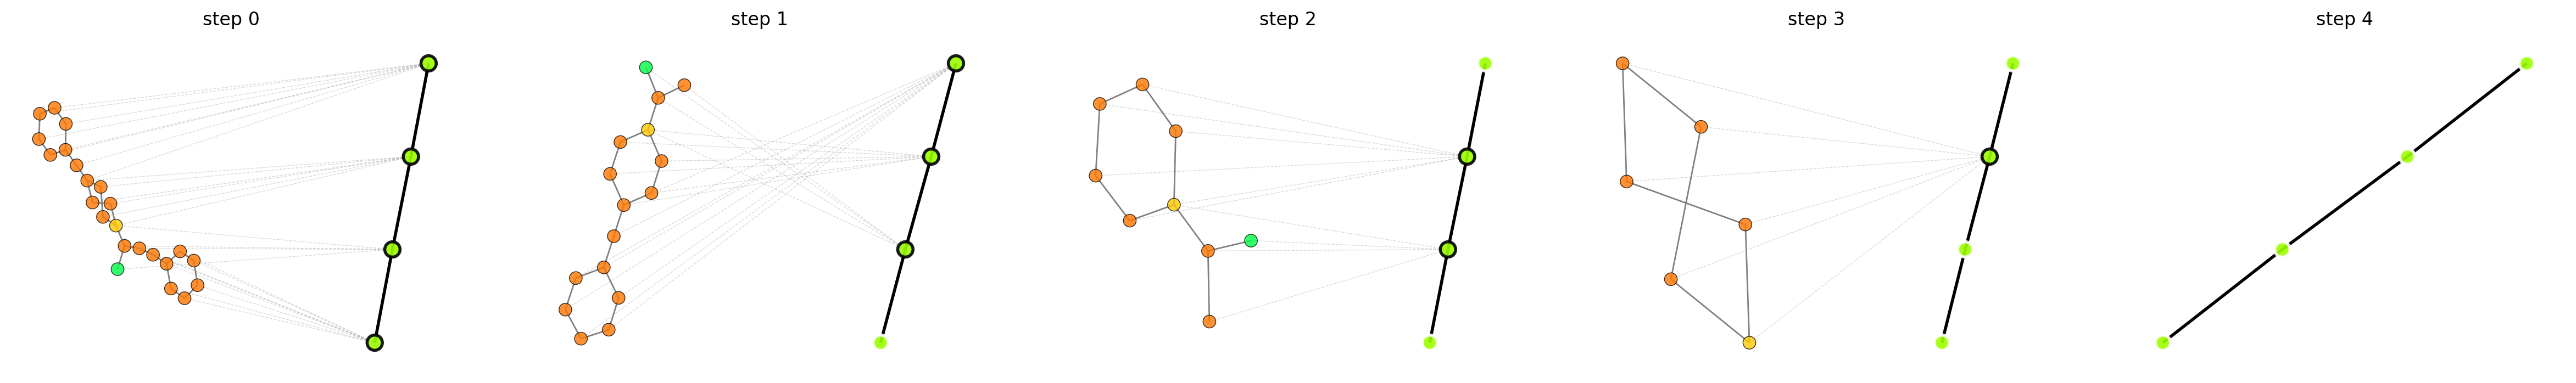

In [10]:
# Visualize a pruning sequence using mapped-subgraph-aware pruning
from abstractgraph_generative.legacy.conditional_v0_1 import generate_image_conditioned_pruning_sequences

example_graph = graphs[2]

# Build the fixed interpretation graph once from the example graph
seed_ag = graph_to_abstract_graph(
    example_graph,
    decomposition_function=decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
)
fixed_interpretation_graph = seed_ag.interpretation_graph.copy()
pre_steps, interpretation_steps = generate_image_conditioned_pruning_sequences(
    example_graph,
    decomposition_function=decomposition_function,
    nbits=nbits,
    label_mode=label_mode,
    base_cut_radius=generator.base_cut_radius,
    interpretation_cut_radius=generator.interpretation_cut_radius,
    preimage_context_radius=generator.preimage_context_radius,
    image_context_radius=generator.image_context_radius,
    context_vectorizer=generator.context_vectorizer,
    use_context_embedding=generator.use_context_embedding,
    fixed_interpretation_graph=fixed_interpretation_graph,
    return_interpretation_steps=True,
    include_start=True,
)

if pre_steps:
    titles = [f"step {i}" for i in range(len(pre_steps))]
    display_conditioned_graphs(
        pre_steps,
        interpretation_steps,  # <-- per-step interpretation graphs with removed_images
        n_graphs_per_line=5,
        titles=titles,
        show=True,
    )
else:
    print('No pruning steps to display.')

vectorizer n_jobs=12 backend=loky
Generator graph group size: 7
Cut size summary (size:count): 0:35, 1:754, 2:397
[candidate-stats] done=    0/7 assigned=   0/19 backtracks=      0 dead_state_skips=      0 img_node=     12 preimage_hash= 211372 accept_prob= 1.0000 parent_preimages=      - entries=   1059 zero_prob_skip=      0 anchor_filter_reject=      0 anchor_outer_count_reject=      0 anchor_outer_empty_reject=      0 anchor_cut_hash_reject=      0 anchor_map_reject=      0 edge_constraint_reject=      0 feasibility_reject=      0 relaxed_anchor_phase=      0 partial_anchor_phase=      0 transition_primary=      1 transition_fallback=      0 accepted=      4
[candidate-stats] done=    0/7 assigned=   1/19 backtracks=      0 dead_state_skips=      0 img_node=      1 preimage_hash= 211372 accept_prob= 1.0000 parent_preimages=211372:1.0000 entries=   1059 zero_prob_skip=      0 anchor_filter_reject=      0 anchor_outer_count_reject=      0 anchor_outer_empty_reject=      0 anchor_cut_

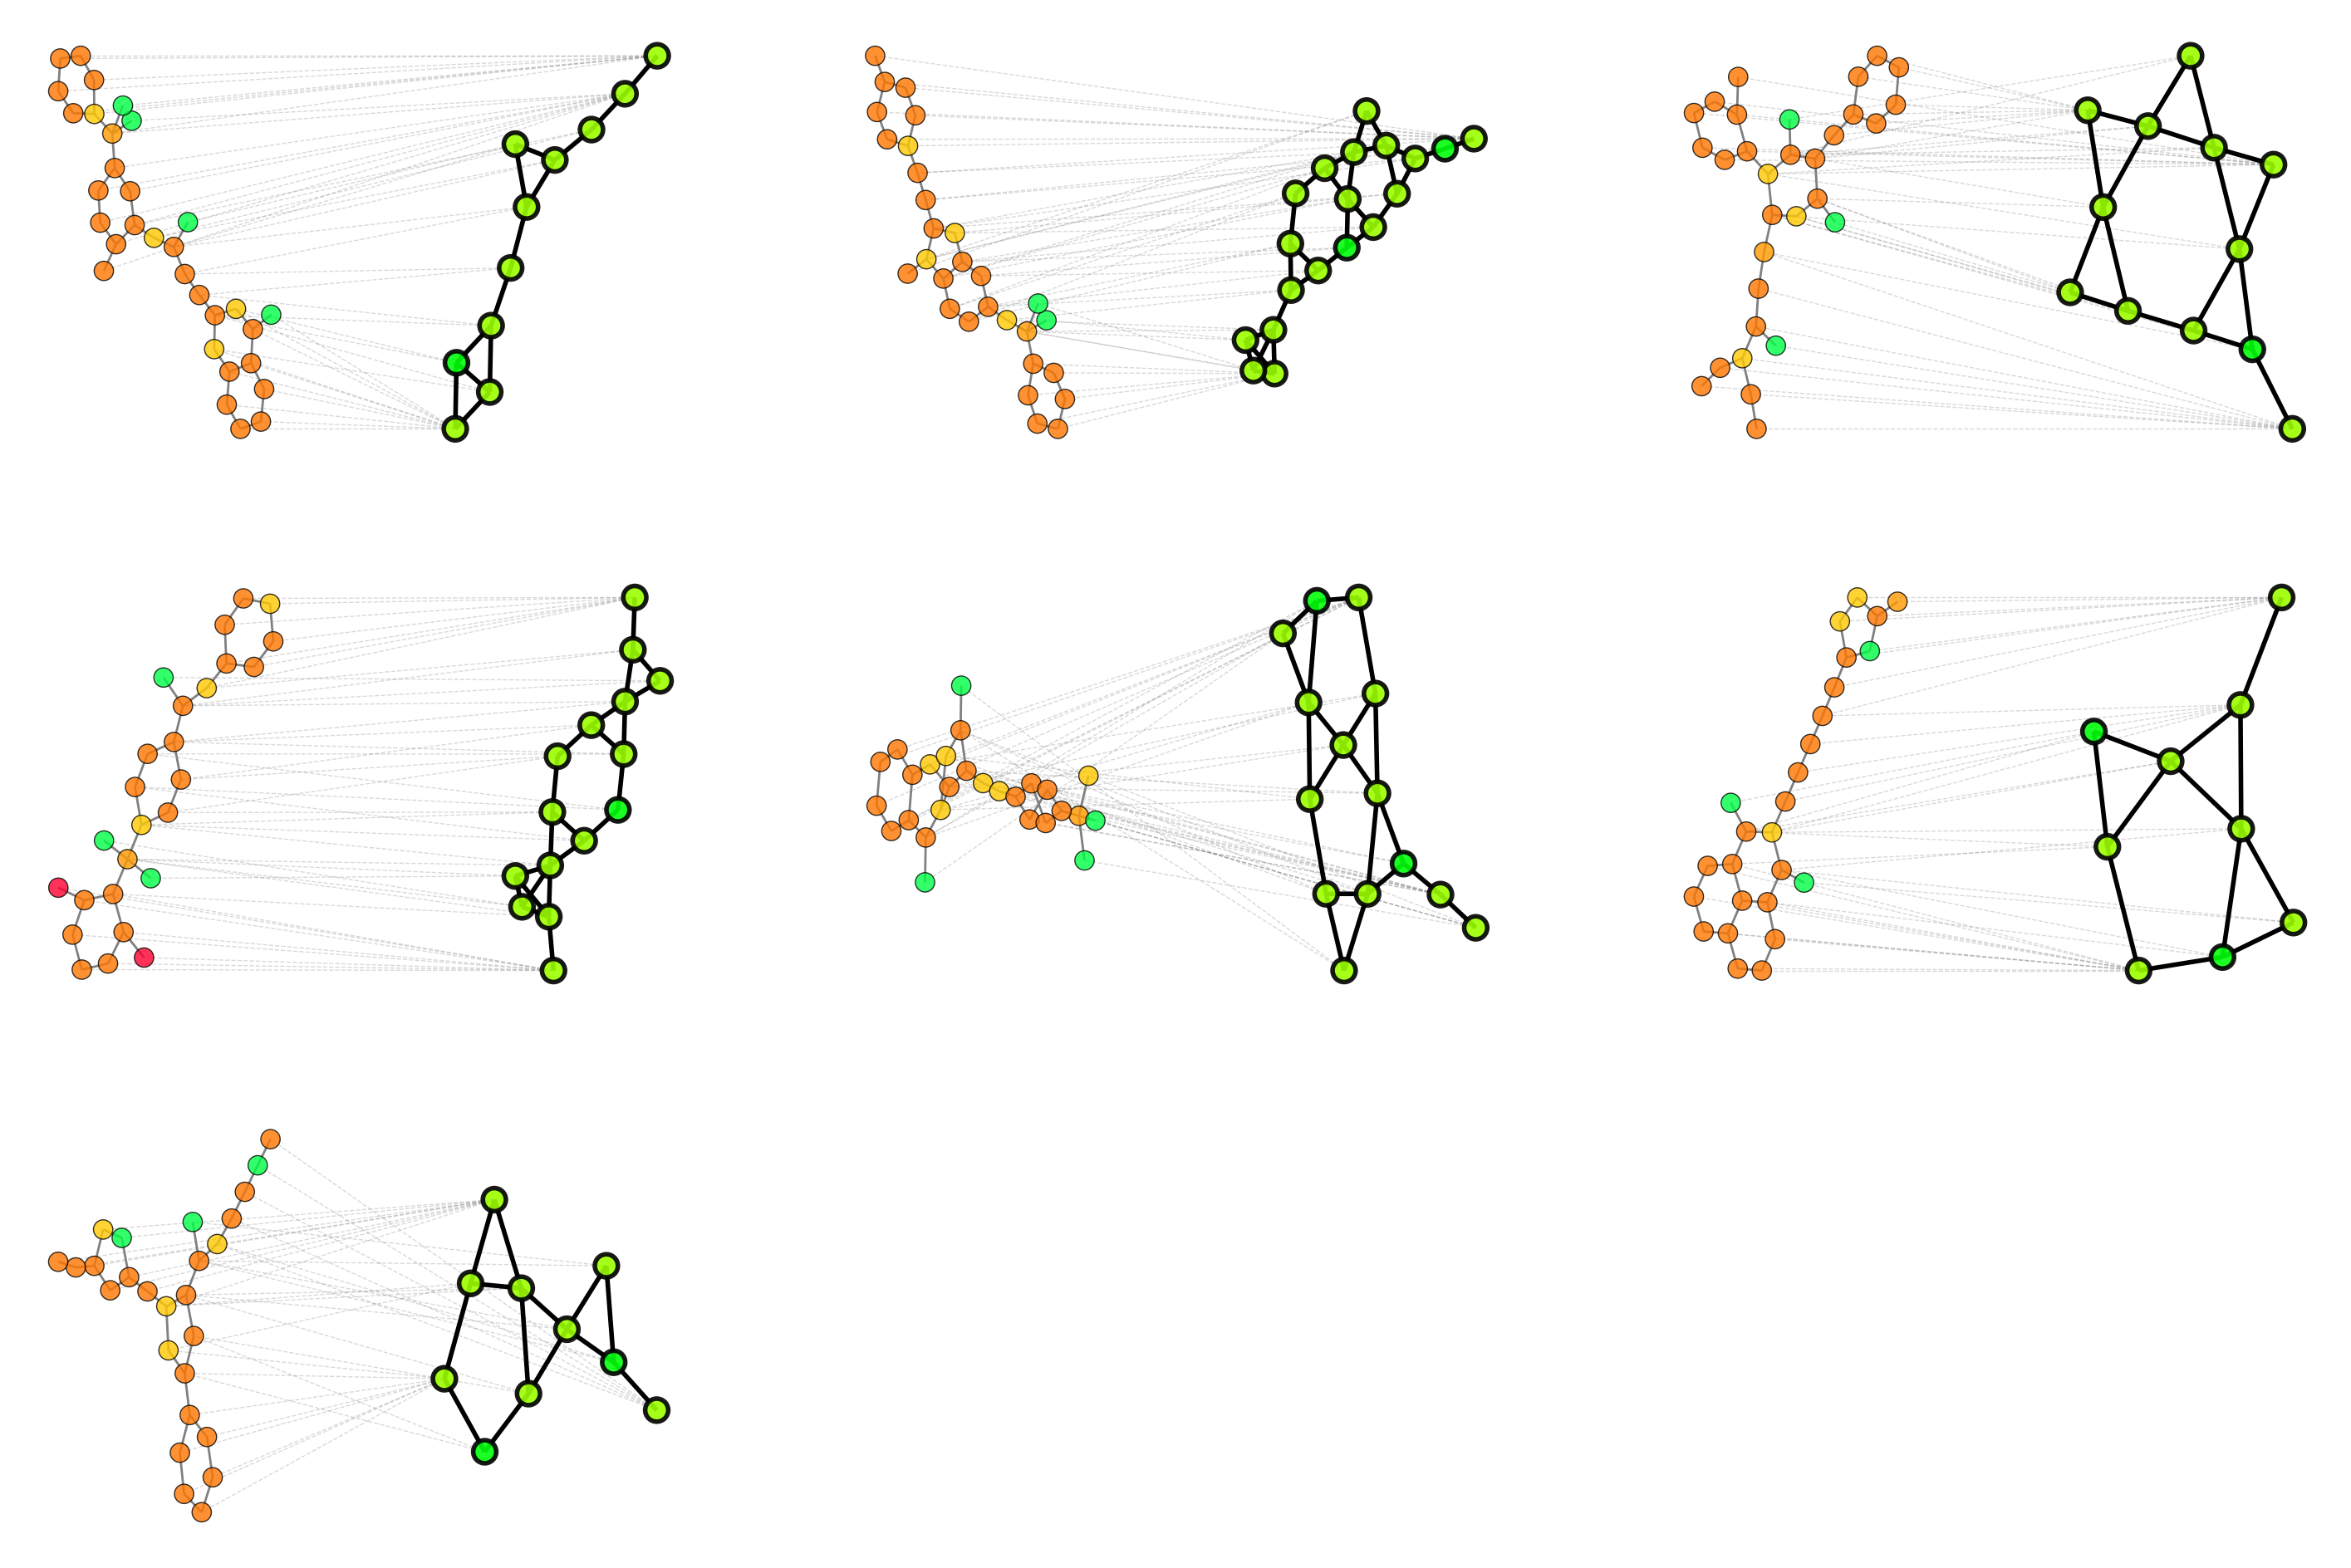

Cut index build time: 59.10s
Generated graphs:
generator_graphs: 7


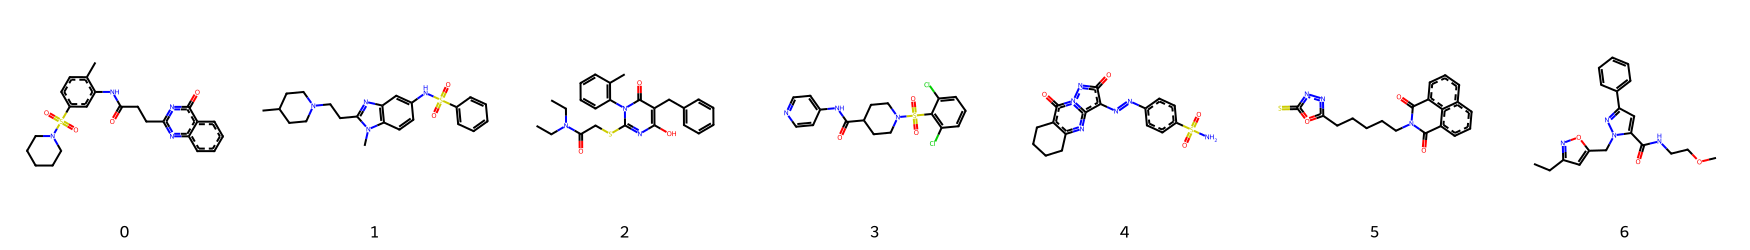

samples: 0
novel samples: 0
All generated samples:
CPU times: user 1min 6s, sys: 2.19 s, total: 1min 8s
Wall time: 1min


In [11]:
%%time
samples = generate_graphs(
    graphs,
    generator,
    mode='nn', # nn  same_image
    constraint_level=1,
    use_context_embedding=False,
    use_transition_primary=True,
    generator_size=7,
    n_samples=7,
    n_pruning_iterations=5,
    verbose=True,
    return_history=False,
    max_attempts_multiplier=12,
    generator_selection_seed=1,
    generation_seed=None,
    render_outputs=False,
    n_jobs_override=1,
)

---